In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as st
import numpy as np
# import statannotations
import scipy
import statsmodels.api as sm
from pathlib import Path
from collections import defaultdict
from scipy.optimize import least_squares
import pubchempy as pcp

In [5]:
repo_folder = Path('../../..')
data_folder  = repo_folder / 'data'/ 'this_project' / '6_transporterKO' / 'Z_div'


# Merge metabolite information

In [51]:
classification_fn = data_folder / 'F_ecmdb_classification.tsv'
df_classyfire = pd.read_csv(classification_fn, sep='\t')    

In [55]:
df_classyfire.columns = ['sid', 'smiles', 'kingdom', 'superclass', 'class', 'subclass',
       'direct_parent', 'geometric_descriptor', 'alternative parents',
       'substituents']

In [56]:
class_dict = {}
for i, row in df_classyfire.iterrows():
    if row['superclass'] == 'Organic acids and derivatives':
        if row['class'] == 'Carboxylic acids and derivatives':
            if row['subclass'] == 'Amino acids, peptides, and analogues':
                class_dict[row['smiles']] = 'Amino acids'
            else:
                class_dict[row['smiles']] = 'Carboxylic acids'
        elif row['class'] in ['Keto acids and derivatives', 'Hydroxy acids and derivatives']:
            class_dict[row['smiles']] = 'Keto / hydroxy acids'
        else:
            class_dict[row['smiles']] = 'Other organic acids'
    elif row['superclass'] == 'Organic oxygen compounds':
        class_dict[row['smiles']] = 'Organic oxygen compounds'
    elif row['superclass'] == 'Nucleosides, nucleotides, and analogues':
        class_dict[row['smiles']] = 'Nucleotides / nucleosides'
    elif row['superclass']=='Organoheterocyclic compounds':
        class_dict[row['smiles']] = 'Organoheterocyclic compounds'
    elif row['superclass']=='Benzenoids':
        class_dict[row['smiles']] = 'Benzenoids'
    elif row['superclass'] == 'Lipids and lipid-like molecules':
        class_dict[row['smiles']] = 'Lipid-like molecules'
    elif row['superclass'] == 'Organic nitrogen compounds':
        class_dict[row['smiles']] = 'Organic nitrogen compounds'
    elif row['superclass'] == 'Phenylpropanoids and polyketides':
        class_dict[row['smiles']] = 'Phenylpropanoids and polyketides'
    else:
        class_dict[row['smiles']] = 'Other'

In [57]:
df_classyfire['Classification'] = df_classyfire['smiles'].map(class_dict)

In [41]:
full_df = pd.merge(df, df_classyfire, left_on='SMILES', right_on='smiles', how='left')

In [42]:
full_df.drop(columns=['sid', 'METLIN', 'Exact match', 'smiles', 'substituents', 'alternative parents', 'direct_parent'], inplace=True)

In [43]:
full_df.fillna({'Classification': 'Unknown'}, inplace=True)

In [44]:
full_df.to_csv(data_folder / 'G_metabolite_info.tsv', sep = '\t', index=False, header=True)

# Plots etc

<Axes: xlabel='class'>

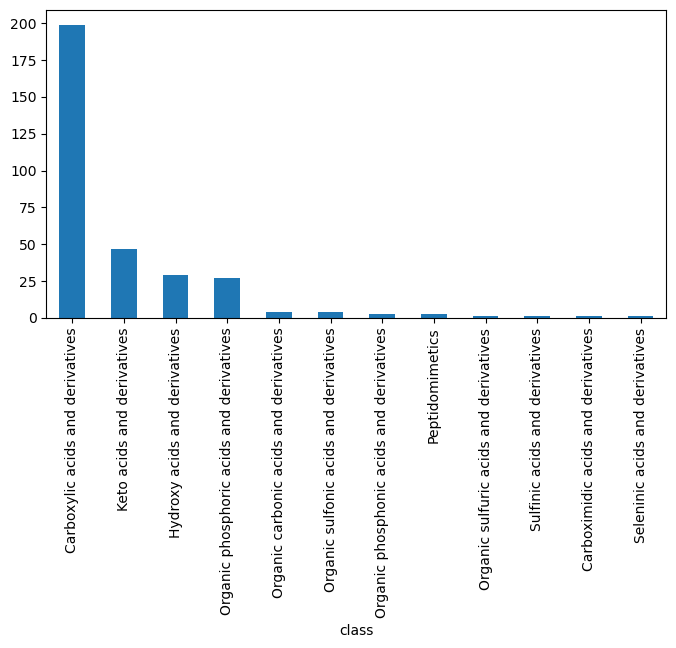

In [15]:
full_df.loc[full_df['superclass']=='Organic acids and derivatives', 'class'].value_counts().plot(kind='bar', figsize=(8,4))

<Axes: xlabel='superclass'>

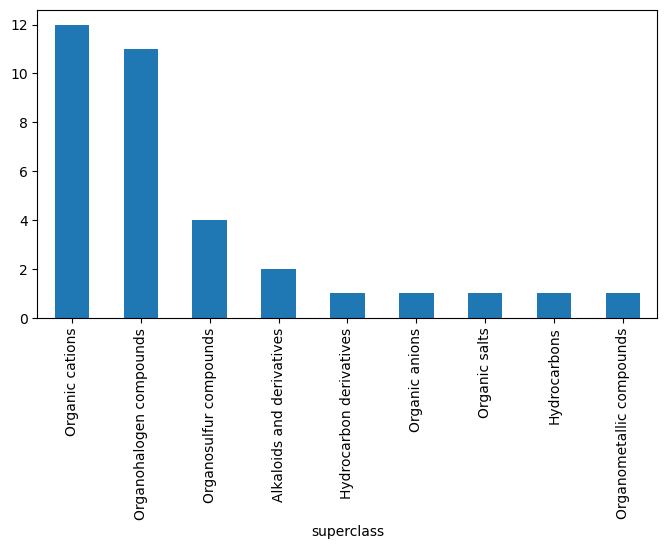

In [16]:
df_classyfire.loc[df_classyfire['Classification']=='Other', 'superclass'].value_counts().plot(kind='bar', figsize=(8,4))

Text(0.5, 0, 'Class')

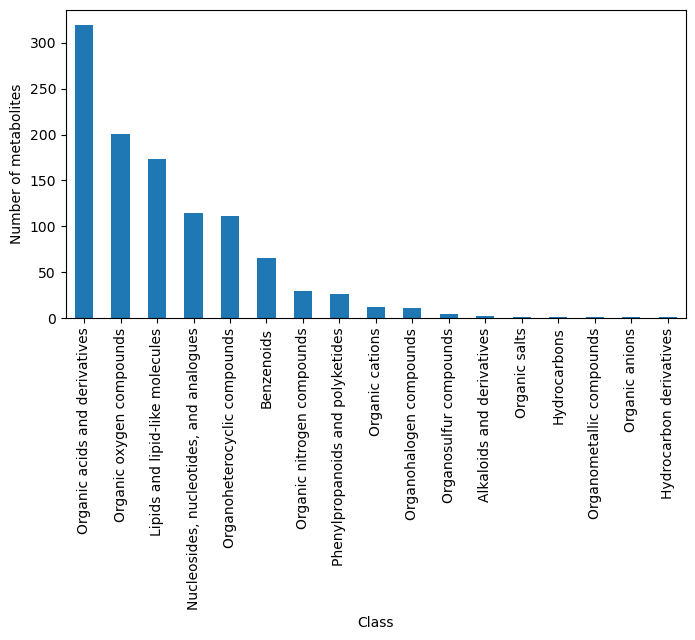

In [17]:
full_df['superclass'].value_counts().plot(kind='bar', figsize=(8,4))
plt.ylabel('Number of metabolites')
plt.xlabel('Class')

In [19]:
# Split and explode rows with multiple KEGG IDs
classify_df = classify_df.reset_index()
classify_df['KEGG ID'] = classify_df['KEGG ID'].str.split(',')
classify_df = classify_df.explode('KEGG ID')
classify_df['KEGG ID'] = classify_df['KEGG ID'].str.strip()
classify_df = classify_df.set_index('index')

NameError: name 'classify_df' is not defined

In [ ]:
# Drop duplicates
classify_df.drop_duplicates(subset='KEGG ID', inplace=True)

In [ ]:
all_info_df = pd.merge(left = kegg_to_inchi_df, right = classify_df, left_on='KEGG', right_on='KEGG ID', how='left')

In [ ]:
all_info_df.to_csv(repo_folder / 'data' / '9_div' / 'all_metabolites_info.csv', index=False)

In [ ]:
all_info_df

,KEGG,ChEBI,Chemical Name,InChI Code,InChIKey,Score,SMILES,Metabolite ID,Name,InChI,...,Charge,abbrv,CompoundID,Class,Direct_parent,Kingdom,Subclass,Superclass,Defined class,KEGG ID
0,C00001,CHEBI:15377\nCHEBI:25698\nCHEBI:29375\nCHEBI:3...,"oxidane\nwater\nUDP\nPurified Water\nWater, Pu...",InChI=1S/H2O/h1H2,XLYOFNOQVPJJNP-UHFFFAOYSA-N,1.0,NaN,h2o,H2O H2O,XLYOFNOQVPJJNP-UHFFFAOYSA-N,...,0.0,h2o,H2O H2O,Homogeneous other non-metal compounds,Homogeneous other non-metal compounds,Inorganic compounds,NaN,Homogeneous non-metal compounds,Other,C00001
1,C00001,CHEBI:15377\nCHEBI:25698\nCHEBI:29375\nCHEBI:3...,"oxidane\nwater\nUDP\nPurified Water\nWater, Pu...",InChI=1S/H2O/h1H2,XLYOFNOQVPJJNP-UHFFFAOYSA-N,1.0,NaN,h2o,H2O H2O,XLYOFNOQVPJJNP-UHFFFAOYSA-N,...,0.0,h2o,H2O H2O,Homogeneous other non-metal compounds,Homogeneous other non-metal compounds,Inorganic compounds,NaN,Homogeneous non-metal compounds,Other,C00001
2,C00002,CHEBI:15422,"[[(2R,3S,4R,5R)-5-(6-aminopurin-9-yl)-3,4-dihy...",InChI=1S/C10H16N5O13P3/c11-8-5-9(13-2-12-8)15(...,ZKHQWZAMYRWXGA-KQYNXXCUSA-N,1.0,NaN,atp,ATP C10H12N5O13P3,ZKHQWZAMYRWXGA-KQYNXXCUSA-J,...,-4.0,atp,ATP C10H12N5O13P3,Purine nucleotides,Purine ribonucleoside triphosphates,Organic compounds,Purine ribonucleotides,"Nucleosides, nucleotides, and analogues",Other,C00002
3,C00003,CHEBI:15846,"[[(2R,3S,4R,5R)-5-(6-aminopurin-9-yl)-3,4-dihy...",InChI=1S/C21H27N7O14P2/c22-17-12-19(25-7-24-17...,BAWFJGJZGIEFAR-NNYOXOHSSA-O,1.0,NaN,nad,Nicotinamide adenine dinucleotide,BAWFJGJZGIEFAR-NNYOXOHSSA-M,...,-1.0,nad,Nicotinamide adenine dinucleotide,(5'->5')-dinucleotides,(5'->5')-dinucleotides,Organic compounds,NaN,"Nucleosides, nucleotides, and analogues",Other,C00003
4,C00004,CHEBI:16908,"NAD\nNicotinamide-Adenine-Dinucleotide\n[[(2R,...",InChI=1S/C21H29N7O14P2/c22-17-12-19(25-7-24-17...,BOPGDPNILDQYTO-NNYOXOHSSA-N,1.0,NaN,nadh,Nicotinamide adenine dinucleotide - reduced,BOPGDPNILDQYTO-NNYOXOHSSA-L,...,-2.0,nadh,Nicotinamide adenine dinucleotide - reduced,(5'->5')-dinucleotides,(5'->5')-dinucleotides,Organic compounds,NaN,"Nucleosides, nucleotides, and analogues",Other,C00004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1867,C22458,No result,No result,No result,NaN,0.0,No result,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1868,C22501,No result,No result,No result,NaN,0.0,No result,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1869,C22502,No result,No result,No result,NaN,0.0,No result,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1870,C22507,No result,No result,No result,NaN,0.0,No result,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [1]:
import json

In [6]:
ecmdb_fn = repo_folder / 'data'/ 'Other' / 'ecmdb.json' 
with open(ecmdb_fn, 'r') as f:
    ecmdb = json.load(f)

In [7]:
ecmdb_df = pd.DataFrame(ecmdb)

In [8]:
# Drop rows with missing KEGG IDs
ecmdb_df = ecmdb_df.dropna(subset=['kegg_id'])

In [9]:
len(ecmdb_df)

1482

In [50]:
smiles_df = pd.DataFrame(ecmdb_df.moldb_smiles.unique(), columns = ['smiles'])
smiles_df.dropna(inplace=True)
smiles_df['inchikey']=''
smiles_df[['inchikey','smiles']].to_csv(data_folder / 'E_smiles_ecmdb.csv', index=False)

In [ ]:
all_ecmdb_kegg_ids = ecmdb_df.dropna(subset='kegg_id').kegg_id.unique()
#all_ecmdb_kegg_ids.to_csv(data_folder / 'C_ecmdb_kegg_ids.csv', index=False, header=False)

In [11]:
ecmdb_df['kegg_id'].isna()

0       False
1       False
2       False
3       False
4       False
        ...  
2854    False
2855    False
2856    False
2857    False
2858    False
Name: kegg_id, Length: 1482, dtype: bool

In [12]:
len(all_ecmdb_kegg_ids)

1198